In [1]:
from pyHepMC3 import HepMC3 as hm3
import pyNuHepMC as nhm
import pyProSelecta as ps

In [2]:
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.100000Ev.hepmc3.gz")

In [3]:
!bash zcat "neut.EDRMF.DCC5D.MicroBooNE.100000Ev.hepmc3.gz" | head -244

HepMC::Version 3.03.01
HepMC::Asciiv3-START_EVENT_LISTING
W CV
T NEUT\|6.2.0\|https://doi.org/10.1140/epjs/s11734-021-00287-7
A NuHepMC.Beam.EnergyUnit GEV
A NuHepMC.Beam.RateUnit #frac{Number of #nu_{#mu}}{1.592 #upoint 10^{20} POT cm^{2} 0.05 GeV}
A NuHepMC.Beam.Type Histogram
A NuHepMC.Beam[14].Histogram.BinContent 24627200.000000 94533000.000000 122210496.000000 145618000.000000 180872496.000000 199318496.000000 213119008.000000 223194496.000000 236011488.000000 246111008.000000 251703504.000000 252103984.000000 248851504.000000 246293504.000000 243755008.000000 238064512.000000 229157984.000000 219608496.000000 210062496.000000 198866000.000000 188562000.000000 176640496.000000 164375504.000000 152730000.000000 141608496.000000 128901504.000000 117326000.000000 105118000.000000 92988000.000000 81045496.000000 70605496.000000 60962504.000000 51810000.000000 43676452.000000 36912152.000000 30574598.000000 25366850.000000 20513850.000000 16732200.000000 13520550.000000 10791800.00000

In [4]:
evt = hm3.GenEvent()

In [5]:
# read the first 5 events and print everything in them
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.100000Ev.hepmc3.gz")
while True: #slightly ugly reading paradigm that is outside of my control
    rdr.read_event(evt)    
    if rdr.failed():
        break


    if evt.event_number() > 5:
        break
    
    hm3.Print.content(evt)

--------------------------------
--------- EVENT CONTENT --------
--------------------------------

Weights (1): 
 1Attributes:
0: NEUT.modene
0: NEUT.passthrough.doubles
0: NEUT.passthrough.fields.doubles
0: NEUT.passthrough.fields.floats
0: NEUT.passthrough.fields.ints
0: NEUT.passthrough.floats
0: NEUT.passthrough.ints
0: lab_pos
2: remnant_particle_number
0: signal_process_id
0: tot_xs
GenParticlePtr (9)
GenParticle:   1 PDGID: 1000180400 (P,E)=+0.00e+00,+0.00e+00,+0.00e+00,+0.00e+00 Stat: 20 PV: 0 EV: -1 Attr: 0
GenParticle:   2 PDGID: 2009900000 (P,E)=+0.00e+00,+0.00e+00,+0.00e+00,+0.00e+00 Stat: 3 PV: -1 EV: -2 Attr: 1 remnant_particle_number=1000180390
GenParticle:   3 PDGID: 2009900000 (P,E)=+0.00e+00,+0.00e+00,+0.00e+00,+0.00e+00 Stat: 1 PV: -2 EV: 0 Attr: 0
GenParticle:   4 PDGID:    14 (P,E)=+0.00e+00,+0.00e+00,+7.79e+02,+7.79e+02 Stat: 4 PV: 0 EV: -3 Attr: 0
GenParticle:   5 PDGID:  2112 (P,E)=-6.24e+01,-5.05e+00,-1.78e+02,+9.58e+02 Stat: 21 PV: -1 EV: -3 Attr: 0
GenPartic

In [6]:
muon_momentum_list = []

rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.100000Ev.hepmc3.gz")
while True:
    rdr.read_event(evt)    
    if rdr.failed():
        break
    
    # only care about events that has exactly 1 outgoing muon
    if not ps.event.has_exact_out_part(evt, ps.pdg.kMuon, 1):
        continue
    
    # grab the muon particle object
    muon = ps.event.hm_out_part(evt, ps.pdg.kMuon)
    # get its momentum in GeV/c
    muon_momentum = ps.p3mod(muon) / ps.unit.GeV_c
    muon_momentum_list.append(muon_momentum)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

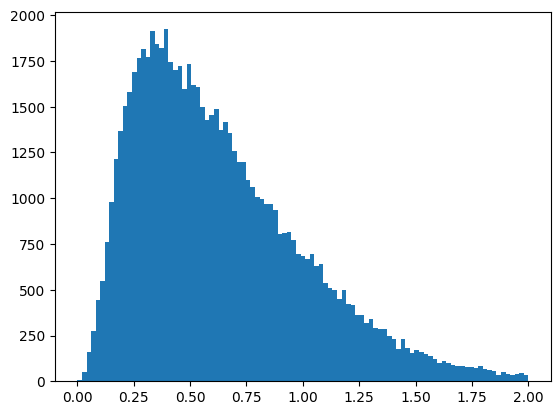

In [8]:
plt.hist(muon_momentum_list, bins=np.linspace(0,2,100))
plt.show()

# Analysis Structure

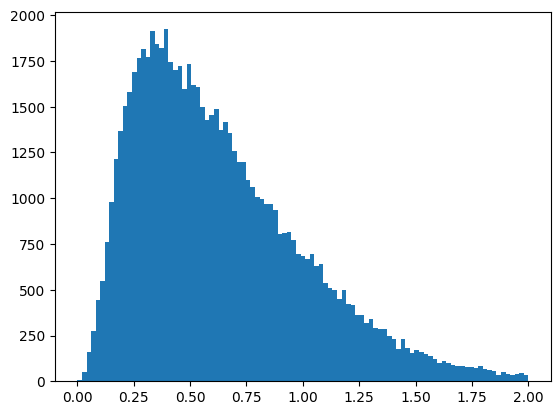

In [9]:
def passes_selection(evt):
    # only care about events that has exactly 1 outgoing muon
    if not ps.event.has_exact_out_part(evt, ps.pdg.kMuon, 1):
        return False

    # add other cuts here
    #
    #
    
    return True

def projection(evt):
    # grab the muon particle object
    muon = ps.event.hm_out_part(evt, ps.pdg.kMuon)
    # get its momentum in GeV/c
    return ps.p3mod(muon) / ps.unit.GeV_c

observable_list = []

evt = hm3.GenEvent()
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.100000Ev.hepmc3.gz")
while True:
    rdr.read_event(evt)    
    if rdr.failed():
        break
    
    if not passes_selection(evt):
        continue
    
    observable_list.append(projection(evt))

plt.hist(observable_list, bins=np.linspace(0,2,100))
plt.show()